In [3]:
import pandas as pd
data = pd.read_csv('student_performance_data.csv')
data.head(2)

,student_id,gender,study_hours_per_day,attendance_percentage,assignment_score,midterm_score,final_exam_score,participation_score,internet_access,extra_classes,parent_education,sleep_hours,overall_score,grade
0,100000,Male,4.54,69.98,36.47,70.70,53.10,17.96,Yes,No,Master,8.09,52.3480,D
1,100001,Female,5.26,84.80,34.25,27.92,87.17,11.29,No,Yes,Bachelor,4.73,53.9485,D


In [4]:
# Libraries import
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, r2_score
from xgboost import XGBRegressor
from sklearn.feature_selection import mutual_info_regression
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
print("... Libraries imported ...")

... Libraries imported ...


In [5]:
features = ['attendance_percentage',
       'assignment_score', 'midterm_score', 'final_exam_score',
       'participation_score', 'internet_access', 'extra_classes', 'sleep_hours']
X = data[features]
Y = data.overall_score

In [6]:
train_X, test_X, train_y, test_y = train_test_split(X, Y, train_size=0.8, test_size=0.2)

In [7]:
categorical_cols = [i for i in train_X.columns if train_X[i].dtype == 'object']
numerical_cols = [i for i in train_X.columns if train_X[i].dtype in ['int64', 'float64']]
my_cols = categorical_cols + numerical_cols
train_X = train_X[my_cols]
test_X = test_X[my_cols]

In [8]:
numerical = SimpleImputer(strategy='median')
categorical = Pipeline(steps=[
    ('imp', SimpleImputer(strategy='most_frequent')),
    ('oh', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
preprocessing = ColumnTransformer(transformers=[
    ('num', numerical, numerical_cols),
    ('cat', categorical, categorical_cols)
])
print("... Filling Categorical and Numerical missing values and preprocessing into Pipeline ...")

... Filling Categorical and Numerical missing values and preprocessing into Pipeline ...


In [9]:
XGBModel = Pipeline(steps=[
    ('pipeline', preprocessing),
    ('model', XGBRegressor(learning_rate = 0.05, n_estimators = 400))
])
XGBModel.fit(train_X, train_y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('pipeline', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contai

In [10]:
predict = XGBModel.predict(test_X)
print(mean_absolute_error(test_y, predict))
print(r2_score(test_y, predict) * 100)

0.5174227684631351
99.60103449098223


In [11]:
def mutual_info(X, Y):
    imp = SimpleImputer(strategy='most_frequent')
    X = X.copy()
    for i in X.select_dtypes('object'):
        X[i], _ = X[i].factorize()
    X =  pd.DataFrame(imp.fit_transform(X), columns=X.columns)
    discrete_features = X.dtypes == int
    info = mutual_info_regression(X, Y, discrete_features=discrete_features)
    info = pd.Series(info, name = 'mutual_info', index = X.columns)
    return info.sort_values(ascending=False)

In [12]:
mutual_info(X, Y)

final_exam_score         0.322333
midterm_score            0.177752
assignment_score         0.099286
participation_score      0.031126
internet_access          0.010558
attendance_percentage    0.009537
sleep_hours              0.003960
extra_classes            0.001414
Name: mutual_info, dtype: float64

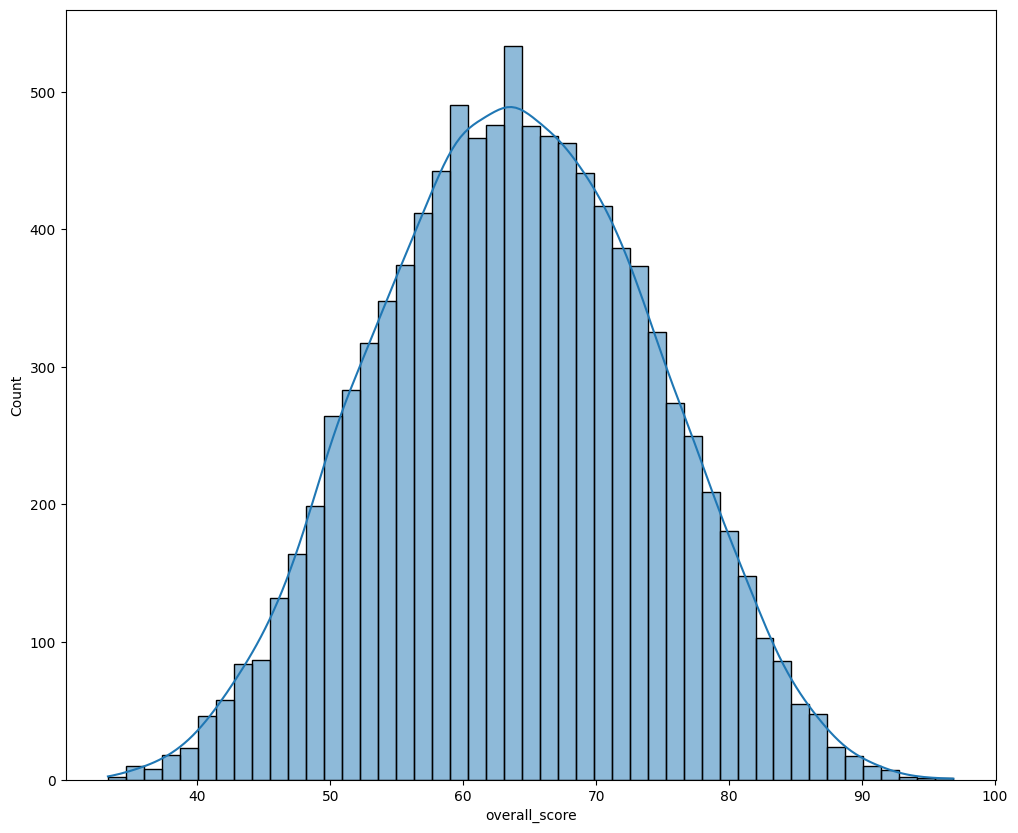

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12, 10))
sns.histplot(data['overall_score'], kde=True)
plt.show()